In [1]:
import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results import * 
import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [2]:
colorgrad = "PuOr"

# 1. Read Data

In [3]:
folder_data = 'data/mc_maze3'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
dset_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))

In [4]:
# corresponding meta data
train_meta = np.load(folder_data + "/meta_train.npy", allow_pickle=True).tolist()
trial_idx_use = np.array(train_meta['trial_info']['trial_version']) == 0
# np.sum(trial_idx_use)

# 2. Behavior Data

In [5]:
trial_type_use = np.array(train_meta['trial_info']['trial_type'])[trial_idx_use]
indices = np.where(trial_idx_use)[0]

target_pos_sel = [train_meta['trial_info']['target_pos'][idx] for idx in indices]
target_pos_sel = np.array(target_pos_sel).squeeze(1).astype(np.float32)

hand_pos_sel = [train_meta['behavior']['hand_pos'][idx] for idx in indices]
cursor_pos_sel = [train_meta['behavior']['cursor_pos'][idx] for idx in indices]
eye_pos_sel = [train_meta['behavior']['eye_pos'][idx] for idx in indices]

# 3. Model Generations

model: latent dim  = 3, lag = 10, re-constrt loss weight = 1 (smaller, previous = 20)

In [6]:
dt = 0.001
eps_clamp = 1e-2
# # no clamp
# clamp_range = None

# # version 1: global clamp (results are similar)
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value - eps_clamp, max_value + eps_clamp]) # give some space

# version 2: clamp dim-by-dim (results are similar)
T_max = max(arr.shape[0] for arr in dset_samples)
padded_arrays = [np.pad(arr, ((0, T_max - arr.shape[0]), (0, 0)),
                        mode='constant', constant_values=np.nan) 
                 for arr in dset_samples]
stacked = np.stack(padded_arrays, axis=0)  # Shape [n_trial, T_max, dim]


min_vals = np.nanmin(stacked, axis=(0, 1))  # Shape [dim]
max_vals = np.nanmax(stacked, axis=(0, 1))  # Shape [dim]

clamp_range = np.stack([min_vals, max_vals], axis=1)  # Shape [dim, 2]
clamp_range[:,0] = clamp_range[:,0] - eps_clamp
clamp_range[:,1] = clamp_range[:,1] + eps_clamp

In [7]:
chk_pts = '/network-snapshot-500000.pkl'
# chk_pts = '/network-snapshot-471654.pkl'

In [8]:
folder_data = 'out/maze/dim3_lag10_eta1/data'
folder = 'out/maze/dim3_lag10_eta1/00000-maze_dim3_lag10_eta1-prr-uncond-regularFM-gpus1-batch256-fp32'
dim_preserve = 3
dset_samples_3_10_eta1, lag_samples_3_10_eta1,\
flow_net_3_10_eta1, dyn_net_3_10_eta1, encoder_3_10_eta1,\
d_3_10_eta1, L_3_10_eta1, loading_3_10_eta1, traj_sim_tau1_3_10_eta1, traj_sim_tau0_3_10_eta1 =\
model_gen(folder_data, folder, chk_pts, dim_preserve, clamp_range, device, useCov = False)
lag = 10
traj_sim_tau1_comp_3_10_eta1 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau1_3_10_eta1[j])) for j in range(len(dset_samples))]
traj_sim_tau0_comp_3_10_eta1 = [np.vstack((dset_samples[j][0:lag], traj_sim_tau0_3_10_eta1[j])) for j in range(len(dset_samples))]

100%|███████████████████████████████████████████| 89/89 [00:01<00:00, 75.04it/s]


project starting points to latent


100%|███████████████████████████████████████████| 89/89 [00:01<00:00, 79.07it/s]


In [9]:
d_3_10_eta1[0:10]
# only display 2 dim (the 3rd dim is totally negligible & make no sense)

tensor([1.8777e-01, 5.2402e-05, 3.8559e-12, 1.5438e-17, 2.0883e-18, 5.1202e-17,
        9.9540e-16, 9.9553e-16, 1.4487e-17, 6.5907e-17], device='cuda:0')

# 5. Latent

In [10]:
theta_deg = get_theta_deg(target_pos_sel)

## 5.1 simulated

In [11]:
dim_preserve = 2
start_plot = 1

In [12]:
traj_sim_tau0_use = traj_sim_tau0_3_10_eta1
encoder_use = encoder_3_10_eta1
dset_samples_use = dset_samples_3_10_eta1
flow_net_use = flow_net_3_10_eta1

In [13]:
mu_traj_sim = latent_mu(traj_sim_tau0_use, encoder_use, dim_preserve, device)
mu_traj_sim_np = [mu_traj_sim[j][start_plot:,:].cpu().numpy() for j in range(len(mu_traj_sim))]

loc_unique, _, mean_traj_sim, _ = mean_traj_by_labels(np.array(mu_traj_sim_np), target_pos_sel)
theta_deg_unique = get_theta_deg(loc_unique)
mean_traj_list_sim = list(mean_traj_sim)

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.18 if use_labels else 0.02, 0.98, 0.98])


Text(0.5, 0.98, 'simulated latent trajc for each trial')

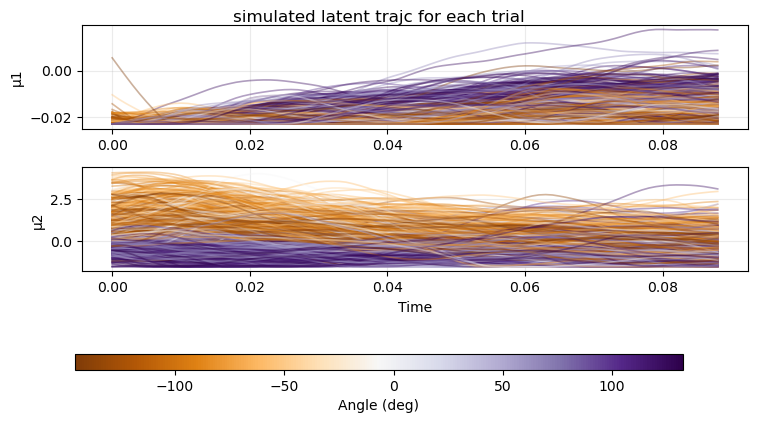

In [14]:
plot_latent_time_series(mu_traj_sim_np, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)
plt.suptitle('simulated latent trajc for each trial')

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'Simulated Latent trajectories'}, xlabel='μ1', ylabel='μ2'>)

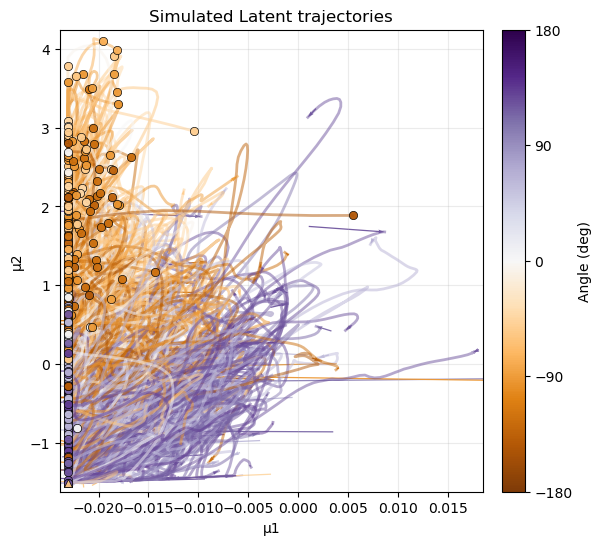

In [15]:
plot_mu_trajectories_gradient_steps_2d(
    mu_traj_sim_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_sim_np)), 
    dims=(0,1),
    title="Simulated Latent trajectories",
    circmap = colorgrad,
)

Text(0.5, 0.98, 'simulated mean latent trajc over target location, all dim_preserve')

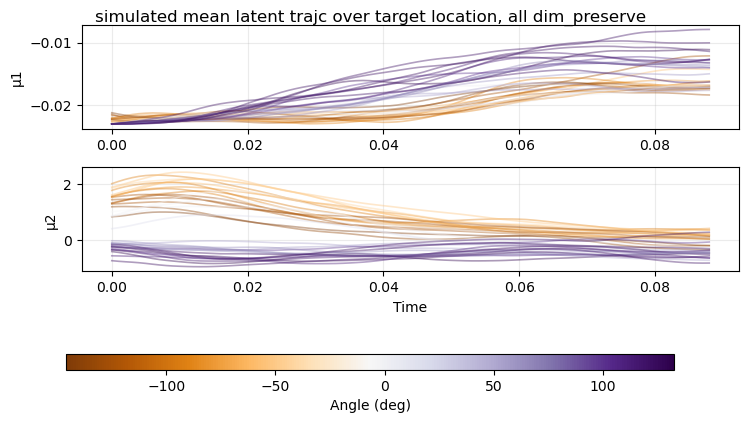

In [16]:
plot_latent_time_series(mean_traj_list_sim, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg_unique, cont_cmap=colorgrad)
plt.suptitle('simulated mean latent trajc over target location, all dim_preserve')

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'Simulated Mean Latent trajectories over target location'}, xlabel='μ1', ylabel='μ2'>)

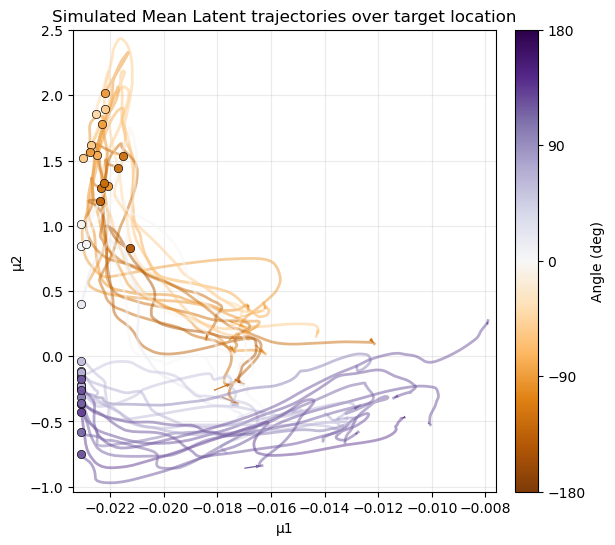

In [17]:
plot_mu_trajectories_gradient_steps_2d(
    mean_traj_list_sim,
    labels=theta_deg_unique,
    trial_indices=np.arange(len(mean_traj_list_sim)), 
    dims=(0,1),
    title="Simulated Mean Latent trajectories over target location",
    circmap = colorgrad,
)

## 5.2 Flowed/ Projected

In [18]:
latent_traj_list = proj_to_latent(dset_samples_use, flow_net_use, 0.0, device)
mu_traj_flow = latent_mu(latent_traj_list, encoder_use, dim_preserve, device)
mu_traj_flow_np = [mu_traj_flow[j][start_plot:,:].cpu().numpy() for j in range(len(mu_traj_flow))]

loc_unique, _, mean_traj_flow, _ = mean_traj_by_labels(np.array(mu_traj_flow_np), target_pos_sel)
theta_deg_unique = get_theta_deg(loc_unique)
mean_traj_list_flow = list(mean_traj_flow)

100%|█████████████████████████████████████████| 592/592 [00:16<00:00, 35.03it/s]


Text(0.5, 0.98, 'flowed latent trajc for each trial, all dim_preserve')

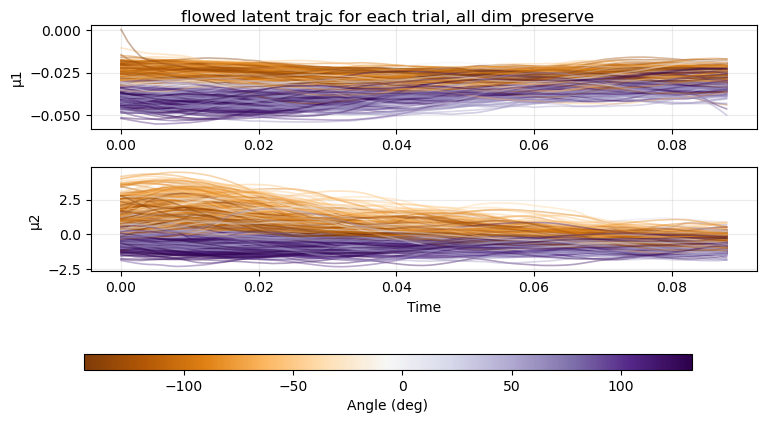

In [19]:
plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg, cont_cmap=colorgrad)
plt.suptitle('flowed latent trajc for each trial, all dim_preserve')

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'Flowed Latent trajectories'}, xlabel='μ1', ylabel='μ2'>)

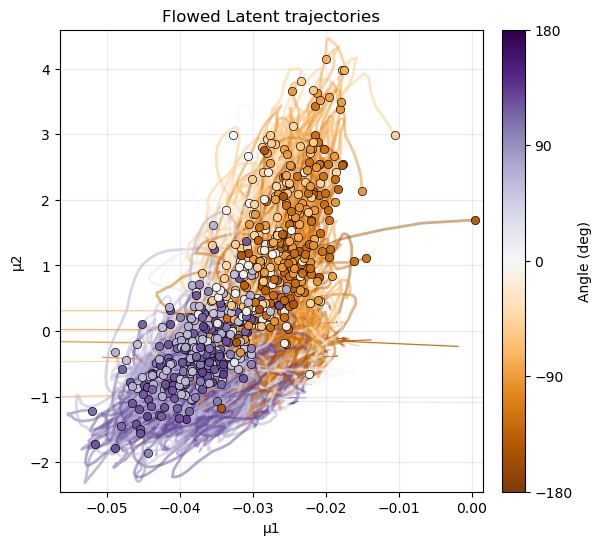

In [20]:
plot_mu_trajectories_gradient_steps_2d(
    mu_traj_flow_np,
    labels=theta_deg,
    trial_indices=np.arange(len(mu_traj_flow_np)), 
    dims=(0,1),
    title="Flowed Latent trajectories",
    circmap = colorgrad,
)

Text(0.5, 0.98, 'flowed mean latent trajc over target location, all dim_preserve')

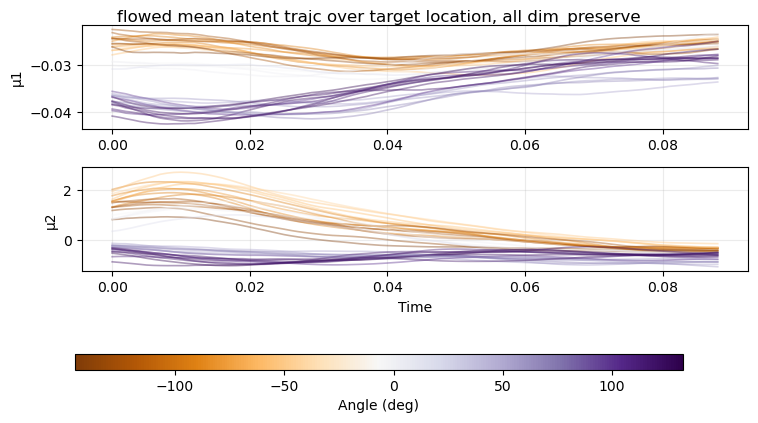

In [21]:
plot_latent_time_series(mean_traj_list_flow, alpha = 0.4, dims=np.arange(dim_preserve), 
                        dt=dt, labels=theta_deg_unique, cont_cmap=colorgrad)
plt.suptitle('flowed mean latent trajc over target location, all dim_preserve')

(<Figure size 600x600 with 2 Axes>,
 <Axes: title={'center': 'Flowed Mean Latent trajectories over target location'}, xlabel='μ1', ylabel='μ2'>)

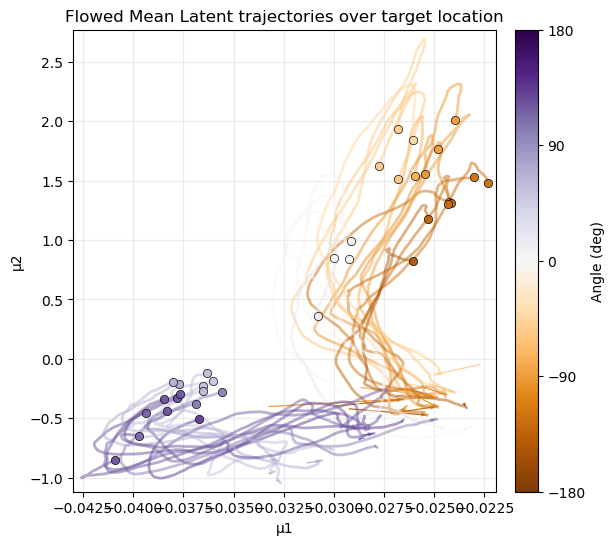

In [22]:
plot_mu_trajectories_gradient_steps_2d(
    mean_traj_list_flow,
    labels=theta_deg_unique,
    trial_indices=np.arange(len(mean_traj_list_flow)), 
    dims=(0,1),
    title="Flowed Mean Latent trajectories over target location",
    circmap = colorgrad,
)